# Cross-Thread Memory with Store API [Step 4 - Long-Term User Profiles]

> **MLCourse - Agentic AI - LangGraph**

This notebook demonstrates how to use the LangGraph Store API and
`InMemoryStore` to persist user preferences and profiles across multiple
conversation threads. While checkpointers handle per-thread state, the Store
provides shared, long-term memory.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv("D:/projects/python/MLCourse/03_agentic_ai/.env")

False

In [2]:
groq_key = os.environ.get("GROQ_API_KEY", "")
if groq_key:
    print("GROQ_API_KEY found")
else:
    print("GROQ_API_KEY not set - using ChatOllama (local, no key needed)")

GROQ_API_KEY not set - using ChatOllama (local, no key needed)


In [3]:
# Core imports for cross-thread memory
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.store.memory import InMemoryStore
from langchain_ollama import ChatOllama

In [4]:
# State schema - includes a field for user profile data
class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
# Initialize local LLM
llm = ChatOllama(model="llama3.1:8b", temperature=0)

In [6]:
# InMemoryStore holds key-value pairs organized by namespace
# Namespaces allow grouping related data (e.g., per user)
store = InMemoryStore()

In [7]:
# Chatbot node that reads and writes user preferences via the store
# The store is accessed through the config at runtime
def chatbot_with_memory(state: ChatState, config):
    # Extract user ID from config namespace
    user_ns = ("user", config["configurable"].get("user_id", "default"))

    # Read existing user profile from the store (None if first visit)
    user_profile = store.get(user_ns, "profile")

    # Build context from stored preferences
    context = ""
    if user_profile:
        context = f"\nKnown user preferences: {user_profile.value}"

    # Prepend context to the message list
    messages_with_context = list(state["messages"])
    if context:
        messages_with_context.insert(0, ("system", f"You have memory about this user.{context}"))

    # Call the LLM with augmented context
    response = llm.invoke(messages_with_context)

    # Extract and store any preference mentions from the user's last message
    last_user_msg = ""
    for msg in reversed(state["messages"]):
        if hasattr(msg, "type") and msg.type == "human":
            last_user_msg = msg.content
            break

    # Simple preference extraction (in production, use an LLM call for this)
    preferences = {}
    if user_profile:
        preferences = dict(user_profile.value) if user_profile.value else {}

    if "favorite color" in last_user_msg.lower():
        # Extract the color from the message
        words = last_user_msg.lower().split()
        for i, w in enumerate(words):
            if w in ["is", "my"] and i + 1 < len(words):
                preferences["favorite_color"] = words[i + 1].strip(".,!?")
                break

    if "name is" in last_user_msg.lower():
        words = last_user_msg.split()
        for i, w in enumerate(words):
            if w.lower() == "is" and i + 1 < len(words):
                preferences["name"] = words[i + 1].strip(".,!?")
                break

    if "i like" in last_user_msg.lower():
        idx = last_user_msg.lower().index("i like") + 6
        preference_text = last_user_msg[idx:].strip().rstrip(".")
        preferences["likes"] = preference_text

    # Persist updated preferences to the store
    if preferences:
        user_ns = ("user", config["configurable"].get("user_id", "default"))
        store.put(user_ns, "profile", preferences)

    return {"messages": [response]}

In [8]:
# Build the graph
graph_builder = StateGraph(ChatState)
graph_builder.add_node("chatbot", chatbot_with_memory)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

In [9]:
# Compile with both checkpointer (per-thread) and store (cross-thread)
checkpointer = MemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer, store=store)

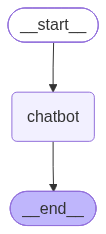

In [10]:
# Visualize the graph
from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization unavailable: {e}")
    print("Graph nodes: START -> chatbot -> END")

In [11]:
# Simulate Session 1 for user "alice" on thread-1
config_alice_1 = {
    "configurable": {
        "thread_id": "alice-session-1",
        "user_id": "alice",
    }
}

response = graph.invoke(
    {"messages": [("user", "Hi, my name is Alice.")]}
    , config_alice_1,
)
print("Alice Session 1 - Turn 1:", response["messages"][-1].content[:100])

response = graph.invoke(
    {"messages": [("user", "My favorite color is purple.")]}
    , config_alice_1,
)
print("Alice Session 1 - Turn 2:", response["messages"][-1].content[:100])

response = graph.invoke(
    {"messages": [("user", "I like hiking and painting.")]}
    , config_alice_1,
)
print("Alice Session 1 - Turn 3:", response["messages"][-1].content[:100])

Alice Session 1 - Turn 1: Hello Alice! It's nice to meet you. Is there something I can help you with or would you like to chat


Alice Session 1 - Turn 2: Purple is a beautiful and rich color. Do you have a particular shade of purple that you especially l


Alice Session 1 - Turn 3: It sounds like you enjoy spending time outdoors and expressing yourself creatively. Hiking must prov


In [12]:
# Check what was stored in the InMemoryStore
user_ns = ("user", "alice")
stored = store.get(user_ns, "profile")
print("Alice's stored profile:", stored.value if stored else "None")

Alice's stored profile:

 {'name': 'Alice', 'favorite_color': 'favorite', 'likes': 'hiking and painting'}


In [13]:
# Simulate Session 2 for user "alice" on a NEW thread
# The store remembers her preferences across sessions
config_alice_2 = {
    "configurable": {
        "thread_id": "alice-session-2",  # new thread
        "user_id": "alice",
    }
}

response = graph.invoke(
    {"messages": [("user", "Hello again! Do you remember me?")]}
    , config_alice_2,
)
print("Alice Session 2 - Turn 1:", response["messages"][-1].content[:100])

Alice Session 2 - Turn 1: I'm glad to see you again, Alice! Yes, I remember you. We've had a conversation before, and I recall


In [14]:
# Simulate Session 1 for user "bob" - separate memory namespace
config_bob_1 = {
    "configurable": {
        "thread_id": "bob-session-1",
        "user_id": "bob",
    }
}

response = graph.invoke(
    {"messages": [("user", "Hi, I am Bob. My favorite color is green.")]}
    , config_bob_1,
)
print("Bob Session 1:", response["messages"][-1].content[:100])

Bob Session 1: Nice to meet you, Bob! Green is a great choice of color - it's calming and natural. Do you have a pa


In [15]:
# Verify both users have separate stored profiles
alice_profile = store.get(("user", "alice"), "profile")
bob_profile = store.get(("user", "bob"), "profile")
print("Alice profile:", alice_profile.value if alice_profile else "None")
print("Bob profile:", bob_profile.value if bob_profile else "None")

Alice profile: {'name': 'Alice', 'favorite_color': 'favorite', 'likes': 'hiking and painting'}
Bob profile: {'favorite_color': 'favorite'}


In [16]:
# List all stored items in the store
all_items = store.search(("user",))
print(f"\nTotal stored user profiles: {len(all_items)}")
for item in all_items:
    print(f"  User: {item.key} -> {item.value}")


Total stored user profiles: 2
  User: profile -> {'name': 'Alice', 'favorite_color': 'favorite', 'likes': 'hiking and painting'}
  User: profile -> {'favorite_color': 'favorite'}


In [17]:
# Cross-thread memory summary
print("\nCross-Thread Memory Summary:")
print("  InMemoryStore: persists data in RAM across threads")
print("  Namespaces organize data (e.g., per user or per entity)")
print("  Checkpointer handles per-thread conversation state")
print("  Store handles shared, long-term user data")
print("  For production, use Redis or database-backed stores")


Cross-Thread Memory Summary:
  InMemoryStore: persists data in RAM across threads
  Namespaces organize data (e.g., per user or per entity)
  Checkpointer handles per-thread conversation state
  Store handles shared, long-term user data
  For production, use Redis or database-backed stores
